In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('cardekho.csv')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


<Axes: xlabel='selling_price'>

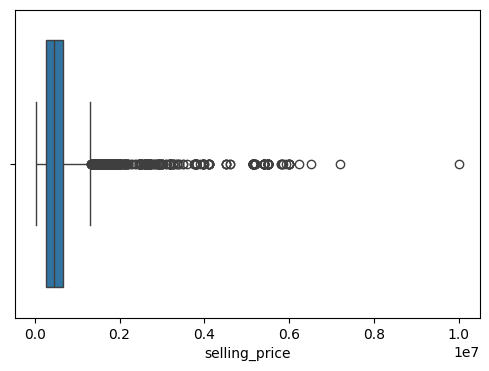

In [4]:
plt.figure(figsize=(6,4))
sns.boxplot(x = df['selling_price'])

In [5]:
Q1 = df['selling_price'].quantile(0.25)
Q3 = df['selling_price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[
    (df['selling_price'] >= lower_bound) &
    (df['selling_price'] <= upper_bound)
]

print("Updated shape:", df.shape)

Updated shape: (7528, 12)


In [6]:
df.shape

(7528, 12)

In [7]:
df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,7528.000000,7.528000e+03,7.528000e+03,7309.000000,7309.000000,7309.000000
mean,2013.529756,4.525882e+05,7.249344e+04,19.678811,1395.475715,5.407443
std,4.046582,2.580495e+05,5.725892e+04,3.967386,456.736488,0.959685
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.500000e+05,3.700000e+04,17.000000,1197.000000,5.000000
50%,2014.000000,4.150000e+05,6.659350e+04,19.700000,1248.000000,5.000000
75%,2017.000000,6.250000e+05,1.000000e+05,22.540000,1498.000000,5.000000
max,2020.000000,1.300000e+06,2.360457e+06,33.440000,3498.000000,14.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7528 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                7528 non-null   object 
 1   year                7528 non-null   int64  
 2   selling_price       7528 non-null   int64  
 3   km_driven           7528 non-null   int64  
 4   fuel                7528 non-null   object 
 5   seller_type         7528 non-null   object 
 6   transmission        7528 non-null   object 
 7   owner               7528 non-null   object 
 8   mileage(km/ltr/kg)  7309 non-null   float64
 9   engine              7309 non-null   float64
 10  max_power           7315 non-null   object 
 11  seats               7309 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 764.6+ KB


In [9]:
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    219
engine                219
max_power             213
seats                 219
dtype: int64

In [10]:
df.dropna(inplace = True)
df.shape

(7309, 12)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7309 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                7309 non-null   object 
 1   year                7309 non-null   int64  
 2   selling_price       7309 non-null   int64  
 3   km_driven           7309 non-null   int64  
 4   fuel                7309 non-null   object 
 5   seller_type         7309 non-null   object 
 6   transmission        7309 non-null   object 
 7   owner               7309 non-null   object 
 8   mileage(km/ltr/kg)  7309 non-null   float64
 9   engine              7309 non-null   float64
 10  max_power           7309 non-null   object 
 11  seats               7309 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 742.3+ KB


In [12]:
df['fuel'].unique()

array(['Diesel', 'Petrol', 'LPG', 'CNG'], dtype=object)

In [13]:
df['seller_type'].unique()

array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

In [14]:
df['transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [15]:
df['owner'].unique()

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner'], dtype=object)

In [16]:
df['max_power'] = df['max_power'].replace('', np.nan)
df['max_power'] = df['max_power'].replace(' ', np.nan)
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')
df.dropna(inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7308 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                7308 non-null   object 
 1   year                7308 non-null   int64  
 2   selling_price       7308 non-null   int64  
 3   km_driven           7308 non-null   int64  
 4   fuel                7308 non-null   object 
 5   seller_type         7308 non-null   object 
 6   transmission        7308 non-null   object 
 7   owner               7308 non-null   object 
 8   mileage(km/ltr/kg)  7308 non-null   float64
 9   engine              7308 non-null   float64
 10  max_power           7308 non-null   float64
 11  seats               7308 non-null   float64
dtypes: float64(4), int64(3), object(5)
memory usage: 742.2+ KB


<Axes: >

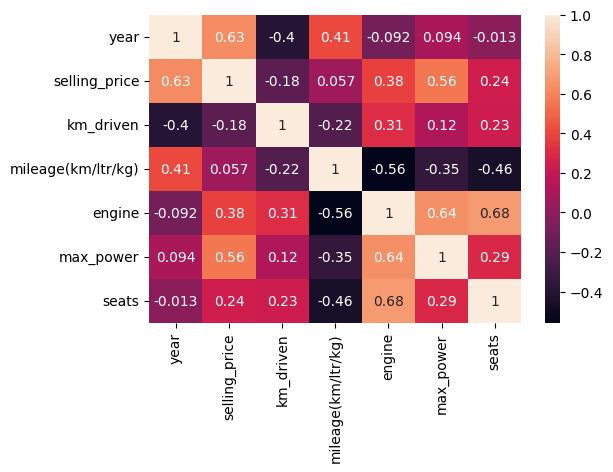

In [17]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only = True),annot = True)

In [18]:
df.select_dtypes(include='object').columns

Index(['name', 'fuel', 'seller_type', 'transmission', 'owner'], dtype='object')

In [19]:
df['fuel'].unique()

array(['Diesel', 'Petrol', 'LPG', 'CNG'], dtype=object)

In [20]:
df['seller_type'].unique()

array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

In [21]:
df['transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [22]:
df['owner'].unique()

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner'], dtype=object)

In [23]:
col = ['fuel', 'seller_type', 'transmission']
df = pd.get_dummies(df , columns= col ,drop_first= True) 

In [24]:
df.head()

,name,year,selling_price,km_driven,owner,mileage(km/ltr/kg),engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,Maruti Swift Dzire VDI,2014,450000,145500,First Owner,23.40,1248.0,74.00,5.0,True,False,False,True,False,True
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Second Owner,21.14,1498.0,103.52,5.0,True,False,False,True,False,True
2,Honda City 2017-2020 EXi,2006,158000,140000,Third Owner,17.70,1497.0,78.00,5.0,False,False,True,True,False,True
3,Hyundai i20 Sportz Diesel,2010,225000,127000,First Owner,23.00,1396.0,90.00,5.0,True,False,False,True,False,True
4,Maruti Swift VXI BSIII,2007,130000,120000,First Owner,16.10,1298.0,88.20,5.0,False,False,True,True,False,True


In [25]:
dummy_cols = df.select_dtypes(include='bool').columns

df[dummy_cols] = df[dummy_cols].astype(int)

In [26]:
df.head()

,name,year,selling_price,km_driven,owner,mileage(km/ltr/kg),engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,Maruti Swift Dzire VDI,2014,450000,145500,First Owner,23.40,1248.0,74.00,5.0,1,0,0,1,0,1
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Second Owner,21.14,1498.0,103.52,5.0,1,0,0,1,0,1
2,Honda City 2017-2020 EXi,2006,158000,140000,Third Owner,17.70,1497.0,78.00,5.0,0,0,1,1,0,1
3,Hyundai i20 Sportz Diesel,2010,225000,127000,First Owner,23.00,1396.0,90.00,5.0,1,0,0,1,0,1
4,Maruti Swift VXI BSIII,2007,130000,120000,First Owner,16.10,1298.0,88.20,5.0,0,0,1,1,0,1


In [27]:
df['owner'] = df['owner'].map({'First Owner' : 0, 'Second Owner':1, 'Third Owner':2,'Fourth & Above Owner':3, 'Test Drive Car':4})

In [28]:
df.head()

,name,year,selling_price,km_driven,owner,mileage(km/ltr/kg),engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,Maruti Swift Dzire VDI,2014,450000,145500,0,23.40,1248.0,74.00,5.0,1,0,0,1,0,1
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,1,21.14,1498.0,103.52,5.0,1,0,0,1,0,1
2,Honda City 2017-2020 EXi,2006,158000,140000,2,17.70,1497.0,78.00,5.0,0,0,1,1,0,1
3,Hyundai i20 Sportz Diesel,2010,225000,127000,0,23.00,1396.0,90.00,5.0,1,0,0,1,0,1
4,Maruti Swift VXI BSIII,2007,130000,120000,0,16.10,1298.0,88.20,5.0,0,0,1,1,0,1


In [29]:
df.drop(columns=['name'], inplace=True)

In [30]:
df.head()

,year,selling_price,km_driven,owner,mileage(km/ltr/kg),engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,2014,450000,145500,0,23.40,1248.0,74.00,5.0,1,0,0,1,0,1
1,2014,370000,120000,1,21.14,1498.0,103.52,5.0,1,0,0,1,0,1
2,2006,158000,140000,2,17.70,1497.0,78.00,5.0,0,0,1,1,0,1
3,2010,225000,127000,0,23.00,1396.0,90.00,5.0,1,0,0,1,0,1
4,2007,130000,120000,0,16.10,1298.0,88.20,5.0,0,0,1,1,0,1


In [31]:
from sklearn.model_selection import train_test_split

X = df.drop(['selling_price'], axis=1)
y = df['selling_price']

In [32]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42)

In [33]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)
print(r2)
n=X_test.shape[0]
p=X_test.shape[1]
ar2 = 1 - ((1-r2) * (n-1) / (n-p-1))
print(ar2)

0.670509855283641
0.6685441040760629


In [35]:
# from sklearn.ensemble import RandomForestRegressor

# rf = RandomForestRegressor(
#     n_estimators=200,
#     random_state=42
# )

# rf.fit(X_train, y_train)

# y_pred = rf.predict(X_test)

# from sklearn.metrics import r2_score
# print("R²:", r2_score(y_test, y_pred))

In [36]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print("Train R²:", xgb.score(X_train, y_train))
print("Test R²:", xgb.score(X_test, y_test))
print("R² Score:", r2_score(y_test, y_pred))

Train R²: 0.9181234836578369
Test R²: 0.8808356523513794
R² Score: 0.8808356523513794


In [37]:
import pickle

# Save model
pickle.dump(model, open('car_price_model.pkl', 'wb'))

In [39]:
import pickle

pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))